This cell merges FH/FHV parquet month files (Aug, Oct, Nov) from the `HVFHV_data` folder into a single Parquet dataset using PySpark. Adjust `months`, `output_path`, and `repartition` as needed for your environment.

In [2]:
from pyspark.sql import SparkSession
import os
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
from datetime import date

from pyspark.sql.functions import (
    to_timestamp, year, month, hour, date_format, dayofmonth, col, when,
    sum as _sum, avg, round as spark_round, dayofweek, to_date, concat_ws
)

spark = SparkSession.builder \
	.appName("HVFHV_analysis") \
	.master("local[*]") \
	.config("spark.driver.memory", "6g") \
	.config("spark.sql.shuffle.partitions", "32") \
	.getOrCreate()




Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
/home/jovinguyen/miniconda3/envs/tf_env/lib/python3.12/site-packages/pyspark/testing/utils.py:127: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()
26/08/29 01:01:03 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


In [3]:
relavent_zones = [246, 50, 48, 158, 186, 68]

df = spark.read.parquet("HVFHV_data/"
                        ).select("request_datetime", "PULocationID", "DOLocationID")
print(df.count(), len(df.columns))

df.printSchema()


297640304 3
root
 |-- request_datetime: timestamp_ntz (nullable = true)
 |-- PULocationID: long (nullable = true)
 |-- DOLocationID: long (nullable = true)



In [4]:
df.show(5)

+-------------------+------------+------------+
|   request_datetime|PULocationID|DOLocationID|
+-------------------+------------+------------+
|2024-10-01 00:35:45|         161|         148|
|2024-10-01 00:47:18|         148|          87|
|2024-10-01 00:02:57|          17|          49|
|2024-10-01 00:44:39|         106|          79|
|2024-10-01 00:07:01|         198|          37|
+-------------------+------------+------------+
only showing top 5 rows


In [5]:
df.count()

297640304

In [6]:
df = df.filter((df.PULocationID.isin(relavent_zones)) | (df.DOLocationID.isin(relavent_zones)))

In [7]:
df.count()

27551246

In [8]:
df.show(5)

+-------------------+------------+------------+
|   request_datetime|PULocationID|DOLocationID|
+-------------------+------------+------------+
|2024-10-01 00:57:55|         234|         186|
|2024-10-01 00:39:35|          68|          87|
|2024-10-01 00:45:31|         186|         265|
|2024-10-01 00:46:15|          48|         186|
|2024-10-01 00:26:30|          48|         127|
+-------------------+------------+------------+
only showing top 5 rows


In [9]:
# add weather condition columns
dt = spark.read.parquet("./Data/zone_weather_map.parquet"
                        ).select("LocationID", "time", "temperature_2m", "precipitation")
dt.show(5)

+----------+-------------------+--------------+-------------+
|LocationID|               time|temperature_2m|precipitation|
+----------+-------------------+--------------+-------------+
|        48|2019-10-01 00:00:00|          17.5|          0.1|
|        48|2019-10-01 01:00:00|          17.4|          0.0|
|        48|2019-10-01 02:00:00|          17.2|          0.0|
|        48|2019-10-01 03:00:00|          16.6|          0.0|
|        48|2019-10-01 04:00:00|          17.3|          0.0|
+----------+-------------------+--------------+-------------+
only showing top 5 rows


In [10]:
from pyspark.sql.functions import to_timestamp, year, month, hour, date_format, dayofmonth, col, when, sum as _sum, avg, round as spark_round

relevant_months = [8, 10, 11]
df = df.withColumn('request_ts', to_timestamp(col('request_datetime')))

pu_in_zone = col('PULocationID').isin(relavent_zones)
do_in_zone = col('DOLocationID').isin(relavent_zones)

# filter early to reduce data volume before aggregation
df = df.filter((pu_in_zone | do_in_zone) & (month(col('request_ts')).isin(relevant_months)))

df = (df
      .withColumn('YEAR', year(col('request_ts')))
      .withColumn('MONTH_NUM', month(col('request_ts')))
      .withColumn('MONTH', date_format(col('request_ts'), 'MMM'))
      .withColumn('DAY', dayofmonth(col('request_ts')))
      .withColumn('HOUR', hour(col('request_ts')))
     )

departure_cond = pu_in_zone & ~do_in_zone
arrival_cond   = ~pu_in_zone & do_in_zone
within_cond    = pu_in_zone & do_in_zone

agg = (
    df.groupBy('YEAR', 'MONTH_NUM', 'MONTH', 'DAY', 'HOUR')
      .agg(
          _sum(when(departure_cond, 1).otherwise(0)).alias('departure_count'),
          _sum(when(arrival_cond, 1).otherwise(0)).alias('arrival_count'),
          _sum(when(within_cond, 1).otherwise(0)).alias('within_count'),
      )
)

result = agg.orderBy('YEAR', 'MONTH_NUM', 'DAY', 'HOUR') \
            .select('YEAR', 'MONTH_NUM', 'MONTH', 'DAY', 'HOUR', 'departure_count', 'arrival_count', 'within_count')
            
result.show(50, truncate=False)

+----+---------+-----+---+----+---------------+-------------+------------+
|YEAR|MONTH_NUM|MONTH|DAY|HOUR|departure_count|arrival_count|within_count|
+----+---------+-----+---+----+---------------+-------------+------------+
|2019|10       |Oct  |1  |0   |541            |495          |80          |
|2019|10       |Oct  |1  |1   |300            |279          |32          |
|2019|10       |Oct  |1  |2   |256            |173          |34          |
|2019|10       |Oct  |1  |3   |176            |132          |27          |
|2019|10       |Oct  |1  |4   |227            |195          |19          |
|2019|10       |Oct  |1  |5   |363            |418          |39          |
|2019|10       |Oct  |1  |6   |747            |710          |100         |
|2019|10       |Oct  |1  |7   |1178           |1023         |168         |
|2019|10       |Oct  |1  |8   |1633           |1447         |286         |
|2019|10       |Oct  |1  |9   |1368           |1308         |304         |
|2019|10       |Oct  |1  

In [11]:
# HOW DO I MERGE THIS WITH THE WEATHER DATA?

# Average weather across all relevant zones, keyed by YEAR/MONTH_NUM/DAY/HOUR

weather_hourly = (
    dt.filter(col('LocationID').isin(relavent_zones))
      .withColumn('YEAR', year(col('time')))
      .withColumn('MONTH_NUM', month(col('time')))
      .withColumn('DAY', dayofmonth(col('time')))
      .withColumn('HOUR', hour(col('time')))
      .groupBy('YEAR', 'MONTH_NUM', 'DAY', 'HOUR')
      .agg(
          spark_round(avg('temperature_2m'), 1).alias('avg_temp'),
          spark_round(avg('precipitation'), 2).alias('avg_precip'),
      )
)

# Left join onto result, keeping result's structure with 2 new columns
result = result.join(weather_hourly, on=['YEAR', 'MONTH_NUM', 'DAY', 'HOUR'], how='left')

result.show(50, truncate=False)

# Sanity check: make sure every row found a weather match
missing_weather = result.filter(col('avg_temp').isNull()).count()
print(f"Rows with missing weather match: {missing_weather}")

+----+---------+---+----+-----+---------------+-------------+------------+--------+----------+
|YEAR|MONTH_NUM|DAY|HOUR|MONTH|departure_count|arrival_count|within_count|avg_temp|avg_precip|
+----+---------+---+----+-----+---------------+-------------+------------+--------+----------+
|2024|10       |1  |1   |Oct  |328            |204          |48          |15.8    |0.0       |
|2024|10       |1  |13  |Oct  |946            |979          |193         |21.5    |0.0       |
|2024|10       |5  |10  |Oct  |1208           |1315         |216         |19.4    |0.0       |
|2024|10       |7  |3   |Oct  |286            |205          |34          |16.4    |0.0       |
|2024|10       |7  |21  |Oct  |1409           |1242         |187         |16.3    |0.0       |
|2024|10       |8  |9   |Oct  |1263           |1393         |264         |13.8    |0.0       |
|2024|10       |9  |10  |Oct  |1072           |1300         |240         |15.8    |0.0       |
|2024|10       |1  |0   |Oct  |589            |371

Rows with missing weather match: 0


In [12]:
# Total rows in the filtered df (should equal every row that touches a relevant zone in a relevant month)
df_row_count = df.count()

# Total counted across the three exclusive classes in result
totals = result.agg(
    _sum('departure_count').alias('total_departure'),
    _sum('arrival_count').alias('total_arrival'),
    _sum('within_count').alias('total_within'),
).collect()[0]

sum_of_classes = totals['total_departure'] + totals['total_arrival'] + totals['total_within']

print(f"Rows in filtered df:        {df_row_count}")
print(f"Departure + Arrival + Within: {sum_of_classes}")
print(f"  Departure: {totals['total_departure']}")
print(f"  Arrival:   {totals['total_arrival']}")
print(f"  Within:    {totals['total_within']}")

if df_row_count == sum_of_classes:
    print("✅ Counts match — partition is complete and non-overlapping.")
else:
    print(f"❌ Mismatch: difference of {df_row_count - sum_of_classes} rows")

Rows in filtered df:        27549411
Departure + Arrival + Within: 27549411
  Departure: 13084468
  Arrival:   12245263
  Within:    2219680
✅ Counts match — partition is complete and non-overlapping.


/home/jovinguyen/miniconda3/envs/tf_env/lib/python3.12/site-packages/pyspark/sql/pandas/conversion.py:298: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()


16 year-month combinations found:
 YEAR  MONTH_NUM MONTH
 2019         10   Oct
 2019         11   Nov
 2020         10   Oct
 2020         11   Nov
 2021         10   Oct
 2021         11   Nov
 2022         10   Oct
 2022         11   Nov
 2023         10   Oct
 2023         11   Nov
 2024          8   Aug
 2024         10   Oct
 2024         11   Nov
 2025          8   Aug
 2025         10   Oct
 2025         11   Nov


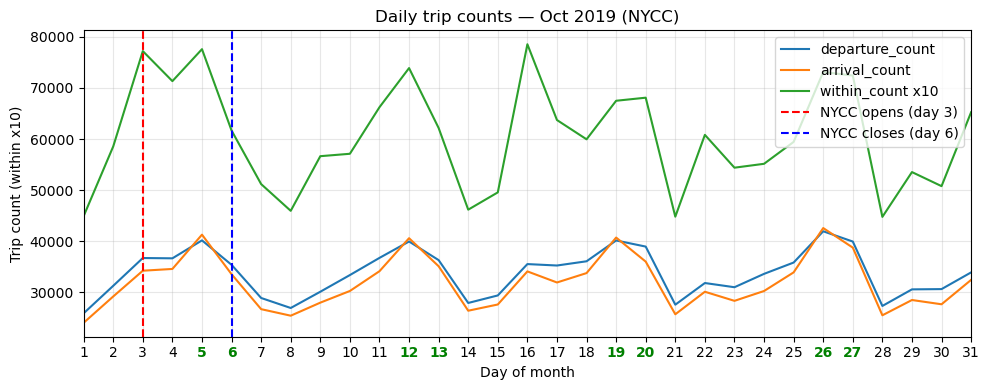

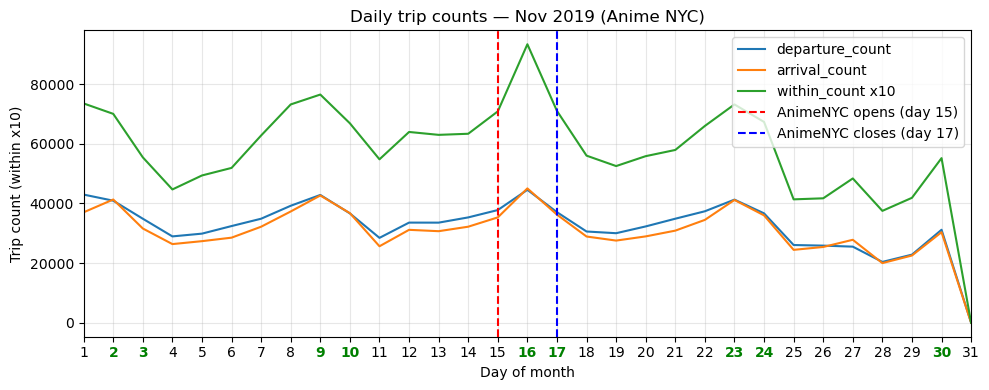

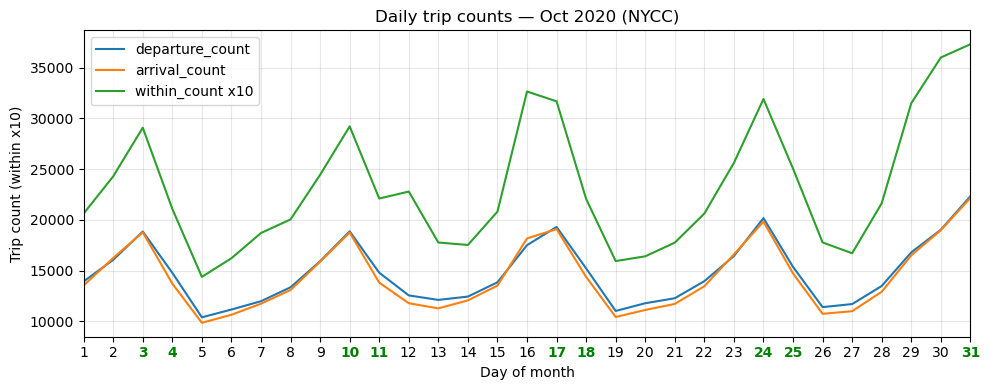

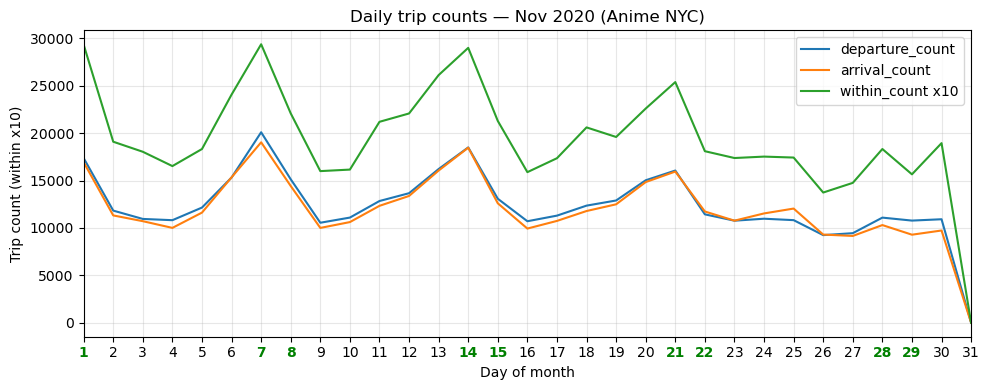

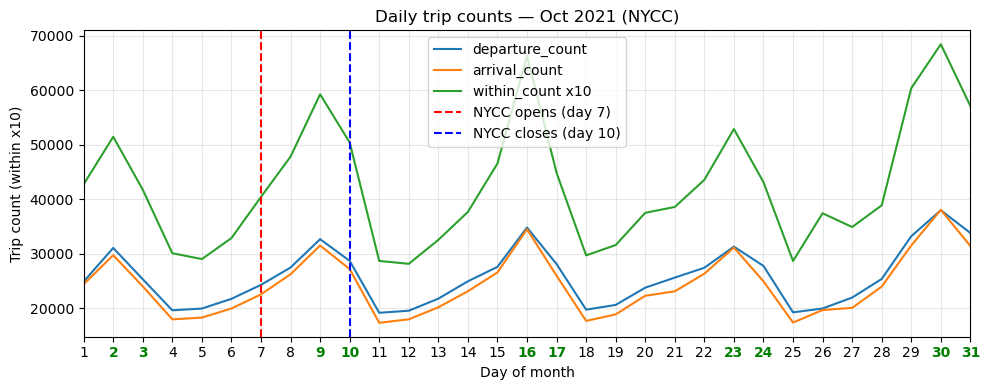

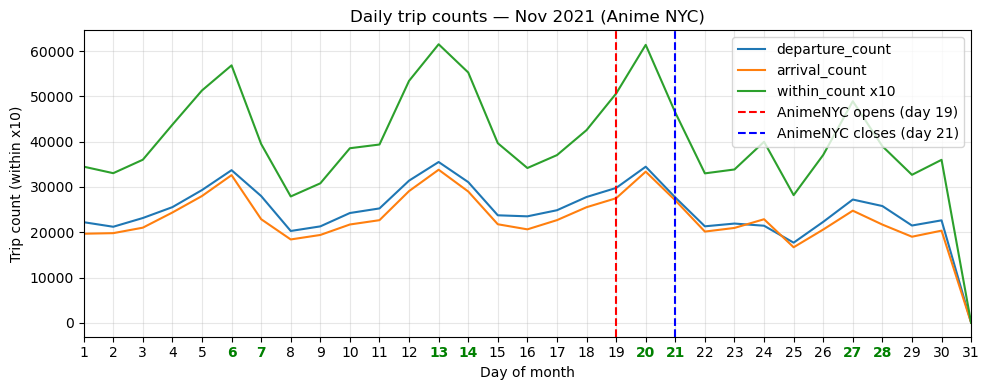

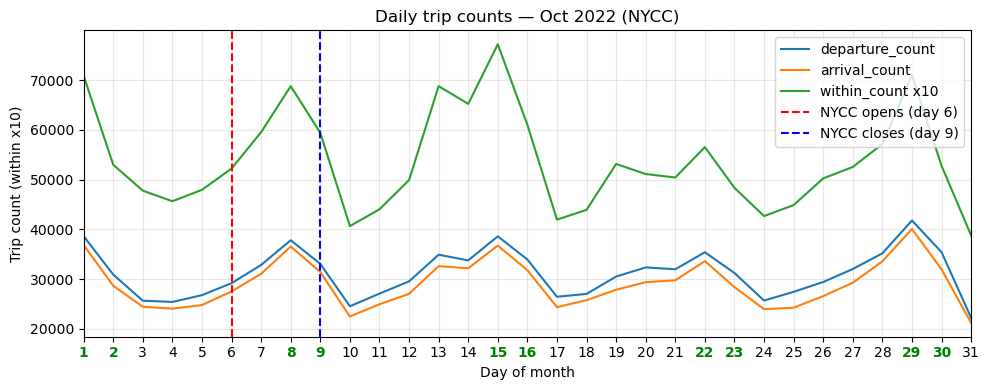

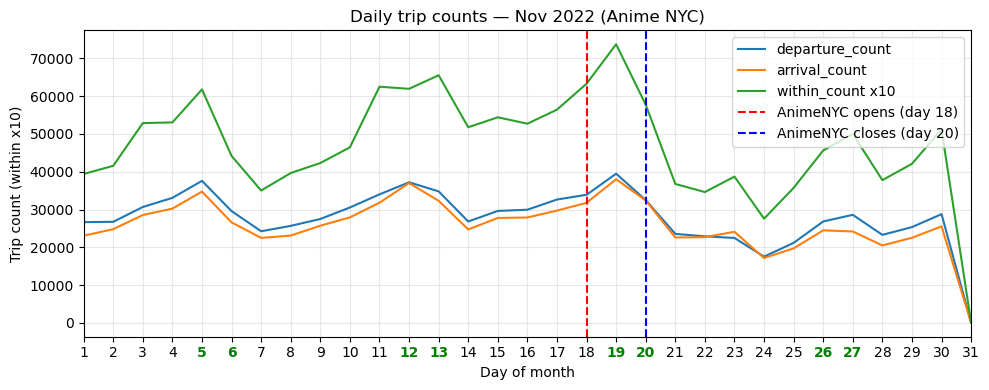

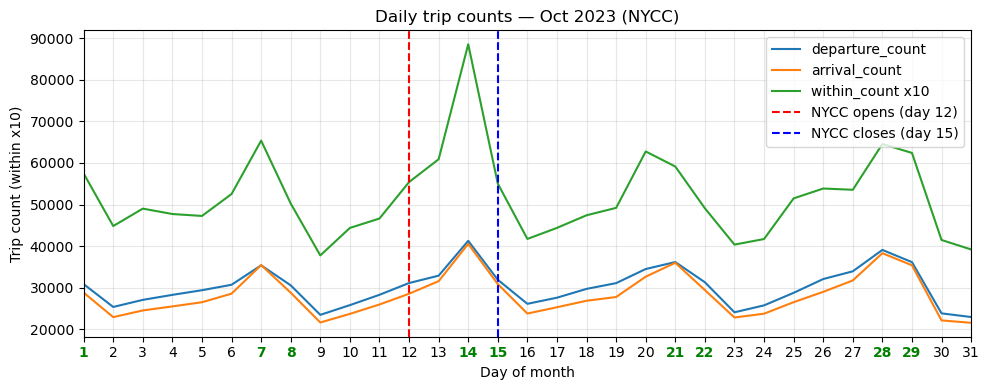

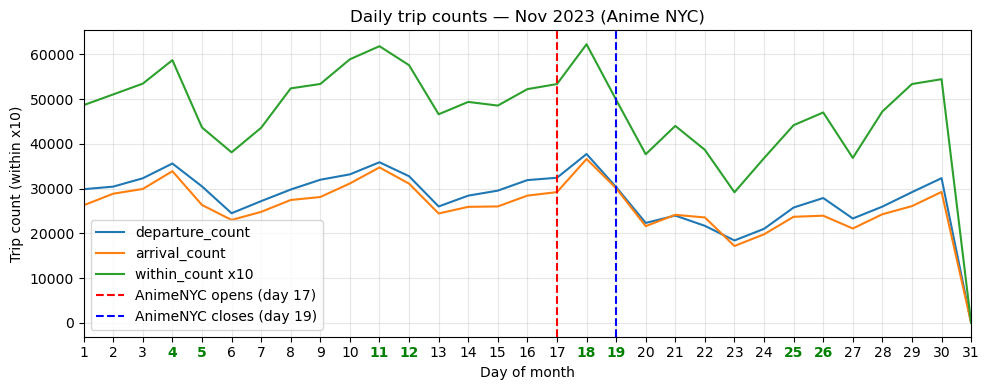

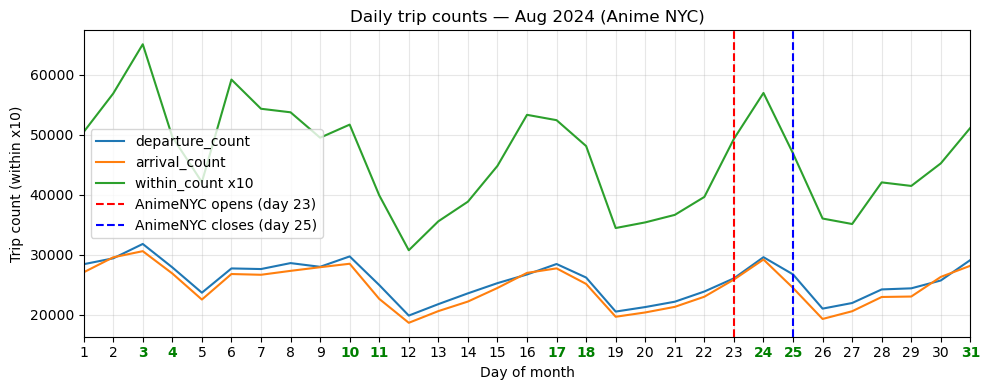

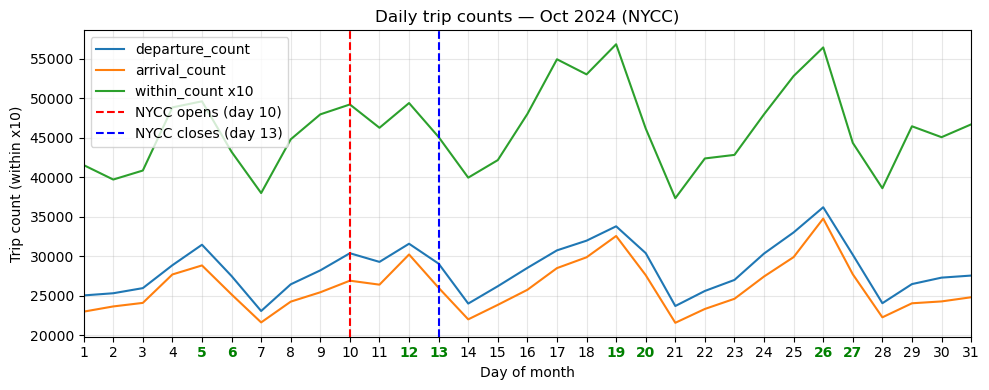

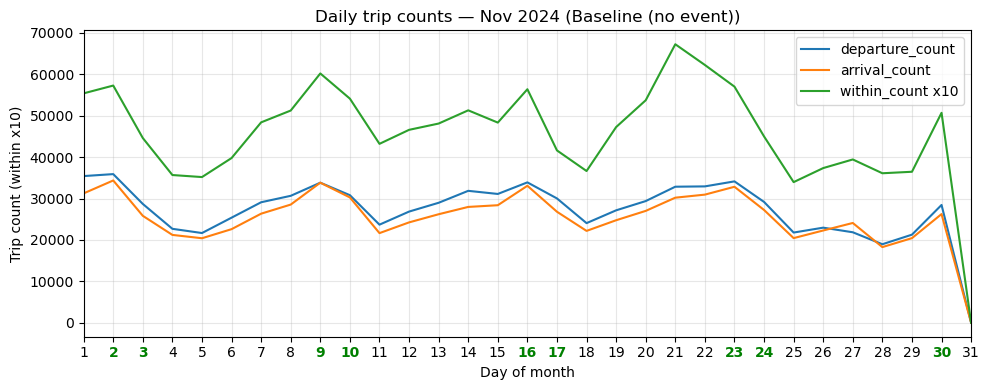

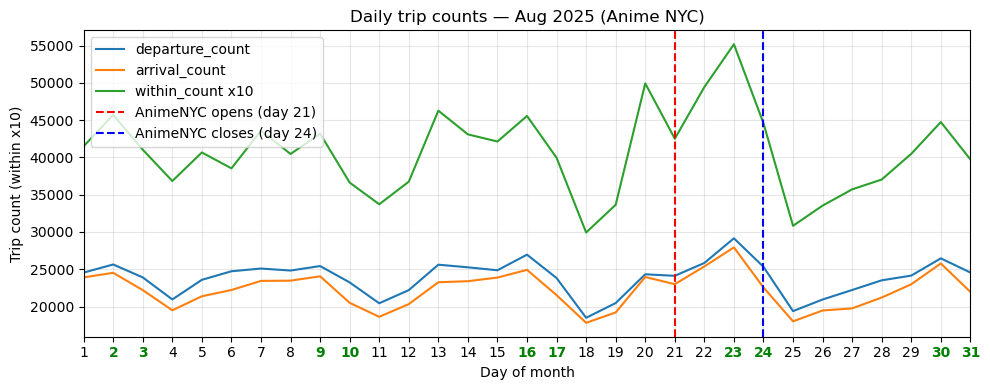

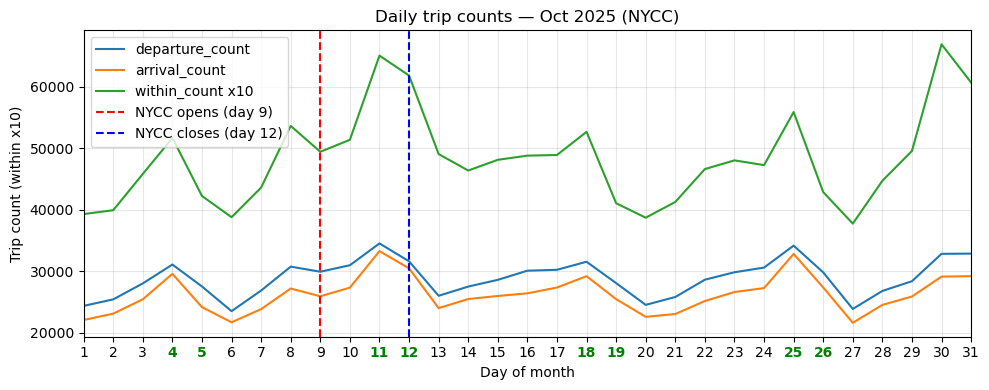

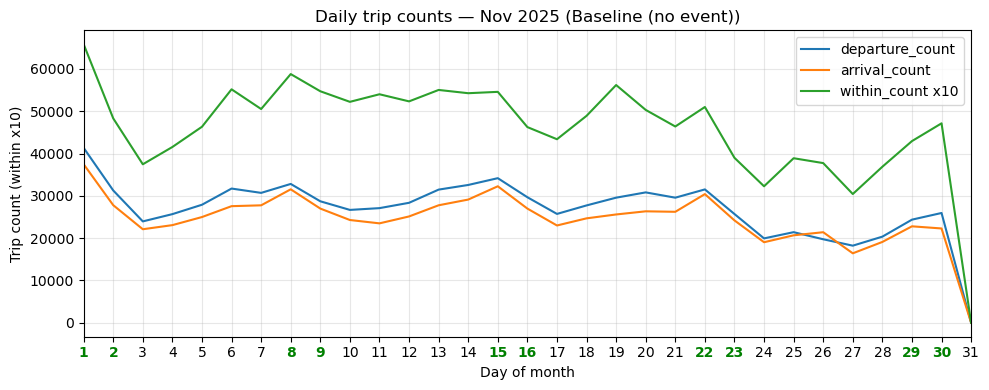

Saved plots to Data/plots


In [13]:
# Roll up hourly to daily totals and plot one figure per (year, month) combination,
# with vertical lines marking each event's opening and closing day,
# and weekend day labels colored green on the x-axis


# Load your verified event hours lookup table
events = pd.read_csv('./Data/nycc_animenyc_event_hours_updated.csv')
events = events.dropna(subset=['date'])  # drop excluded/blank rows (e.g. 2020 COVID years)
events['date'] = pd.to_datetime(events['date'])
events['year'] = events['date'].dt.year
events['month_num'] = events['date'].dt.month
events['day'] = events['date'].dt.day

# For each (event, year, month) find the first day (open) and last day (close)
event_spans = (
    events.groupby(['event', 'year', 'month_num'])
    .agg(open_day=('day', 'min'), close_day=('day', 'max'))
    .reset_index()
)

# Aggregate across hours to daily totals
daily = (
    result.groupBy('YEAR', 'MONTH_NUM', 'MONTH', 'DAY')
    .agg(
        _sum('departure_count').alias('departure_count'),
        _sum('arrival_count').alias('arrival_count'),
        _sum('within_count').alias('within_count'),
    )
    .orderBy('YEAR', 'MONTH_NUM', 'DAY')
)

# Collect to pandas
daily_pd = daily.toPandas()

# Prepare plot folder
plot_dir = 'Data/plots'
os.makedirs(plot_dir, exist_ok=True)

# Map month number -> which event that month/year combo relates to
def label_event(mnum, yr):
    if mnum == 10:
        return 'NYCC'
    elif mnum == 11 and yr <= 2023:
        return 'Anime NYC'
    elif mnum == 8 and yr >= 2024:
        return 'Anime NYC'
    else:
        return 'Baseline (no event)'  # e.g. Nov 2024/2025, Aug pre-2024

# Helper: is a given (year, month, day) a Saturday or Sunday?
def is_weekend(yr, mnum, day):
    try:
        return date(int(yr), int(mnum), int(day)).weekday() >= 5  # 5=Sat, 6=Sun
    except ValueError:
        return False  # day doesn't exist in this month (e.g. day 31 in a 30-day month)

# Get every distinct (YEAR, MONTH_NUM, MONTH) combination actually present — do NOT collapse across months
combos = (
    daily_pd[['YEAR', 'MONTH_NUM', 'MONTH']]
    .drop_duplicates()
    .sort_values(['YEAR', 'MONTH_NUM'])
    .reset_index(drop=True)
)

print(f'{len(combos)} year-month combinations found:')
print(combos.to_string(index=False))

# Plot one figure per (year, month) combination
for _, row in combos.iterrows():
    yr, mnum, mname = row['YEAR'], row['MONTH_NUM'], row['MONTH']
    event_label = label_event(mnum, yr)

    sub = daily_pd[(daily_pd['YEAR'] == yr) & (daily_pd['MONTH_NUM'] == mnum)]
    sub = (
        sub.set_index('DAY')[['departure_count', 'arrival_count', 'within_count']]
        .reindex(range(1, 32), fill_value=0)
    )

    x = sub.index.values
    dep = sub['departure_count'].values
    arr = sub['arrival_count'].values
    within = sub['within_count'].values * 10  # scale up for visibility

    fig, ax = plt.subplots(figsize=(10, 4))
    ax.plot(x, dep, label='departure_count', color='tab:blue')
    ax.plot(x, arr, label='arrival_count', color='tab:orange')
    ax.plot(x, within, label='within_count x10', color='tab:green')

    # Look up this (year, month) in event_spans and draw open/close vertical lines
    match = event_spans[(event_spans['year'] == yr) & (event_spans['month_num'] == mnum)]
    for _, ev_row in match.iterrows():
        ax.axvline(ev_row['open_day'], color='red', linestyle='--', linewidth=1.5,
                   label=f"{ev_row['event']} opens (day {ev_row['open_day']})")
        ax.axvline(ev_row['close_day'], color='blue', linestyle='--', linewidth=1.5,
                   label=f"{ev_row['event']} closes (day {ev_row['close_day']})")

    ax.set_title(f'Daily trip counts — {mname} {yr} ({event_label})')
    ax.set_xlabel('Day of month')
    ax.set_ylabel('Trip count (within x10)')
    ax.set_xlim(1, 31)
    ax.set_xticks(range(1, 32))
    ax.legend()
    ax.grid(alpha=0.3)

    # Color weekend day labels green, weekday labels black
    for tick_label, day_num in zip(ax.get_xticklabels(), range(1, 32)):
        if is_weekend(yr, mnum, day_num):
            tick_label.set_color('green')
            tick_label.set_fontweight('bold')
        else:
            tick_label.set_color('black')

    out_path = os.path.join(plot_dir, f'daily_counts_{yr}_{mname}.png')
    plt.tight_layout()
    plt.savefig(out_path, dpi=150)
    display(fig)
    plt.close()

print('Saved plots to', plot_dir)

In [14]:
# Insert this BEFORE the `model_df = result.toPandas()` cell
from pyspark.sql.functions import dayofweek, to_date, concat_ws

result = (
    result
    .withColumn('date_str', concat_ws('-', col('YEAR'), col('MONTH_NUM'), col('DAY')))
    .withColumn('event_date', to_date(col('date_str'), 'yyyy-M-d'))
    .withColumn('day_of_week', dayofweek(col('event_date')))
)

result.printSchema()  # confirm day_of_week is present before proceeding

root
 |-- YEAR: integer (nullable = true)
 |-- MONTH_NUM: integer (nullable = true)
 |-- DAY: integer (nullable = true)
 |-- HOUR: integer (nullable = true)
 |-- MONTH: string (nullable = true)
 |-- departure_count: long (nullable = true)
 |-- arrival_count: long (nullable = true)
 |-- within_count: long (nullable = true)
 |-- avg_temp: double (nullable = true)
 |-- avg_precip: double (nullable = true)
 |-- date_str: string (nullable = false)
 |-- event_date: date (nullable = false)
 |-- day_of_week: integer (nullable = false)



In [15]:
# Rebuild event_days_pd with open/close hour extracted
events['open_hour'] = pd.to_datetime(events['open_time'], format='%H:%M').dt.hour
events['close_hour'] = pd.to_datetime(events['close_time'], format='%H:%M').dt.hour

event_days_pd = events[['event', 'year', 'month_num', 'day', 'open_hour', 'close_hour']].drop_duplicates()
event_days_pd = event_days_pd.rename(columns={'year': 'YEAR', 'month_num': 'MONTH_NUM', 'day': 'DAY'})

event_days_spark = spark.createDataFrame(event_days_pd)

# Drop any previously-joined event columns before rejoining, so this cell is safe to re-run
cols_to_drop = ['event', 'open_hour', 'close_hour', 'event_flag']
result = result.drop(*[c for c in cols_to_drop if c in result.columns])

result = (
    result
    .join(event_days_spark, on=['YEAR', 'MONTH_NUM', 'DAY'], how='left')
    .withColumn(
        'event_flag',
        (
            col('event').isNotNull() &
            (col('HOUR') >= col('open_hour')) &
            (col('HOUR') < col('close_hour'))
        ).cast('int')
    )
)

result.groupBy('event_flag').count().show()
result.printSchema()

/home/jovinguyen/miniconda3/envs/tf_env/lib/python3.12/site-packages/pyspark/sql/pandas/conversion.py:659: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()
/home/jovinguyen/miniconda3/envs/tf_env/lib/python3.12/site-packages/pyspark/sql/pandas/conversion.py:936: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()
/home/jovinguyen/miniconda3/envs/tf_env/lib/python3.12/site-packages/pyspark/sql/pandas/conversion.py:687: UserWarning: createDataFrame attempted Arrow optimization because 'spark.sql.execution.arrow.pyspark.enabled' is set to true; however, failed by the reason below:
  Cannot grow BufferHolder by size -8 because the size is negative
Attempting non-optimization as 'spark.sql.execution.arrow.pyspark.fallb

+----------+-----+
|event_flag|count|
+----------+-----+
|         1|  353|
|         0|11376|
+----------+-----+

root
 |-- YEAR: integer (nullable = true)
 |-- MONTH_NUM: integer (nullable = true)
 |-- DAY: integer (nullable = true)
 |-- HOUR: integer (nullable = true)
 |-- MONTH: string (nullable = true)
 |-- departure_count: long (nullable = true)
 |-- arrival_count: long (nullable = true)
 |-- within_count: long (nullable = true)
 |-- avg_temp: double (nullable = true)
 |-- avg_precip: double (nullable = true)
 |-- date_str: string (nullable = false)
 |-- event_date: date (nullable = false)
 |-- day_of_week: integer (nullable = false)
 |-- event: string (nullable = true)
 |-- open_hour: long (nullable = true)
 |-- close_hour: long (nullable = true)
 |-- event_flag: integer (nullable = true)



In [16]:
model_df = result.toPandas()
model_df['event_flag'] = model_df['event_flag'].fillna(0).astype(int)
model_df.sample(10, random_state=42)

# save model_df to CSV for downstream modeling
OUTPUT_PATH = 'Data/model_df_with_event_flag.csv'
model_df.to_csv(OUTPUT_PATH, index=False)

/home/jovinguyen/miniconda3/envs/tf_env/lib/python3.12/site-packages/pyspark/sql/pandas/conversion.py:298: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()


In [17]:
# Pick one known Anime NYC day to inspect — Sat Nov 18, 2023: 10am-7pm
check = (
    model_df[
        (model_df['YEAR'] == 2023) &
        (model_df['MONTH_NUM'] == 11) &
        (model_df['DAY'] == 18)
    ]
    .sort_values('HOUR')
    [['HOUR', 'event', 'open_hour', 'close_hour', 'event_flag', 'departure_count', 'arrival_count']]
)

# Check if the event_flag is correctly set for hours 10-18 (10am-6pm) and not set for other hours
print(check.to_string(index=False))

 HOUR    event  open_hour  close_hour  event_flag  departure_count  arrival_count
    0 AnimeNYC       10.0        19.0           0             2064           1532
    1 AnimeNYC       10.0        19.0           0             1781           1238
    2 AnimeNYC       10.0        19.0           0             1387            921
    3 AnimeNYC       10.0        19.0           0             1181            640
    4 AnimeNYC       10.0        19.0           0              737            429
    5 AnimeNYC       10.0        19.0           0              462            456
    6 AnimeNYC       10.0        19.0           0              546            764
    7 AnimeNYC       10.0        19.0           0              584            860
    8 AnimeNYC       10.0        19.0           0              744           1230
    9 AnimeNYC       10.0        19.0           0             1002           1627
   10 AnimeNYC       10.0        19.0           1             1222           1724
   11 AnimeNYC  

In [18]:
import statsmodels.api as sm
import statsmodels.formula.api as smf

formula = "departure_count ~ event_flag + avg_temp + avg_precip + C(MONTH, Treatment(reference='Nov')) + C(YEAR) + C(HOUR) + C(day_of_week)"

dep_model = smf.glm(formula.replace('departure_count', 'departure_count'), data=model_df, family=sm.families.NegativeBinomial()).fit()
arr_model = smf.glm(formula.replace('departure_count', 'arrival_count'), data=model_df, family=sm.families.NegativeBinomial()).fit()
within_model = smf.glm(formula.replace('departure_count', 'within_count'), data=model_df, family=sm.families.NegativeBinomial()).fit()

print(dep_model.summary())
print(arr_model.summary())
print(within_model.summary())

/home/jovinguyen/miniconda3/envs/tf_env/lib/python3.12/site-packages/statsmodels/genmod/families/family.py:1367: ValueWarning: Negative binomial dispersion parameter alpha not set. Using default value alpha=1.0.
  warnings.warn("Negative binomial dispersion parameter alpha not "
/home/jovinguyen/miniconda3/envs/tf_env/lib/python3.12/site-packages/statsmodels/genmod/families/family.py:1367: ValueWarning: Negative binomial dispersion parameter alpha not set. Using default value alpha=1.0.
  warnings.warn("Negative binomial dispersion parameter alpha not "
/home/jovinguyen/miniconda3/envs/tf_env/lib/python3.12/site-packages/statsmodels/genmod/families/family.py:1367: ValueWarning: Negative binomial dispersion parameter alpha not set. Using default value alpha=1.0.
  warnings.warn("Negative binomial dispersion parameter alpha not "


                 Generalized Linear Model Regression Results                  
Dep. Variable:        departure_count   No. Observations:                11729
Model:                            GLM   Df Residuals:                    11688
Model Family:        NegativeBinomial   Df Model:                           40
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -92560.
Date:                Sat, 29 Aug 2026   Deviance:                       1350.6
Time:                        01:02:30   Pearson chi2:                 1.43e+03
No. Iterations:                    11   Pseudo R-squ. (CS):             0.2228
Covariance Type:            nonrobust                                         
                                                  coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------------

In [19]:
import statsmodels.api as sm

# Fit an auxiliary OLS to estimate alpha via the standard NB2 approach,
# or more directly, use statsmodels' NegativeBinomial (not GLM) which estimates alpha itself
from statsmodels.discrete.discrete_model import NegativeBinomial
import statsmodels.formula.api as smf

nb_model_dep = smf.negativebinomial(
    'departure_count ~ event_flag + avg_temp + avg_precip + C(MONTH, Treatment(reference="Nov")) + C(YEAR) + C(HOUR) + C(day_of_week)',
    data=model_df
).fit()

print(nb_model_dep.summary())
print(f"Estimated alpha: {nb_model_dep.params['alpha']}")

Optimization terminated successfully.
         Current function value: 7.180047
         Iterations: 31
         Function evaluations: 37
         Gradient evaluations: 37
                     NegativeBinomial Regression Results                      
Dep. Variable:        departure_count   No. Observations:                11729
Model:               NegativeBinomial   Df Residuals:                    11688
Method:                           MLE   Df Model:                           40
Date:                Sat, 29 Aug 2026   Pseudo R-squ.:                 0.07729
Time:                        01:02:30   Log-Likelihood:                -84215.
converged:                       True   LL-Null:                       -91269.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                                  coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------

In [20]:
nb_model_arr = smf.negativebinomial(
    'arrival_count ~ event_flag + avg_temp + avg_precip + C(MONTH, Treatment(reference="Nov")) + C(YEAR) + C(HOUR) + C(day_of_week)',
    data=model_df
).fit()

print(nb_model_arr.summary())
print(f"Estimated alpha: {nb_model_arr.params['alpha']}")

Optimization terminated successfully.
         Current function value: 7.003788
         Iterations: 27
         Function evaluations: 32
         Gradient evaluations: 32
                     NegativeBinomial Regression Results                      
Dep. Variable:          arrival_count   No. Observations:                11729
Model:               NegativeBinomial   Df Residuals:                    11688
Method:                           MLE   Df Model:                           40
Date:                Sat, 29 Aug 2026   Pseudo R-squ.:                 0.09413
Time:                        01:02:31   Log-Likelihood:                -82147.
converged:                       True   LL-Null:                       -90684.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                                  coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------

In [21]:
nb_model_within = smf.negativebinomial(
    'within_count ~ event_flag + avg_temp + avg_precip + C(MONTH, Treatment(reference="Nov")) + C(YEAR) + C(HOUR) + C(day_of_week)',
    data=model_df
).fit()

print(nb_model_within.summary())
print(f"Estimated alpha: {nb_model_within.params['alpha']}")

         Current function value: 5.419129
         Iterations: 35
         Function evaluations: 40
         Gradient evaluations: 40
                     NegativeBinomial Regression Results                      
Dep. Variable:           within_count   No. Observations:                11729
Model:               NegativeBinomial   Df Residuals:                    11688
Method:                           MLE   Df Model:                           40
Date:                Sat, 29 Aug 2026   Pseudo R-squ.:                  0.1146
Time:                        01:02:31   Log-Likelihood:                -63561.
converged:                      False   LL-Null:                       -71786.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                                  coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------------------------
Intercept 

/home/jovinguyen/miniconda3/envs/tf_env/lib/python3.12/site-packages/scipy/optimize/_optimize.py:1330: OptimizeWarning: Maximum number of iterations has been exceeded.
  res = _minimize_bfgs(f, x0, args, fprime, callback=callback, **opts)
/home/jovinguyen/miniconda3/envs/tf_env/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [22]:
# fit with corrected alpha parameterization

formula_template = (
    '{y} ~ event_flag + avg_temp + avg_precip + '
    'C(MONTH, Treatment(reference="Nov")) + C(YEAR) + C(HOUR) + C(day_of_week)'
)

dep_nb = smf.negativebinomial(formula_template.format(y='departure_count'), data=model_df).fit()
arr_nb = smf.negativebinomial(formula_template.format(y='arrival_count'), data=model_df).fit()
within_nb = smf.negativebinomial(formula_template.format(y='within_count'), data=model_df).fit()

print(dep_nb.summary())
print(f"Departure alpha: {dep_nb.params['alpha']}\n")

print(arr_nb.summary())
print(f"Arrival alpha: {arr_nb.params['alpha']}\n")

print(within_nb.summary())
print(f"Within alpha: {within_nb.params['alpha']}\n")

Optimization terminated successfully.
         Current function value: 7.180047
         Iterations: 31
         Function evaluations: 37
         Gradient evaluations: 37
Optimization terminated successfully.
         Current function value: 7.003788
         Iterations: 27
         Function evaluations: 32
         Gradient evaluations: 32


/home/jovinguyen/miniconda3/envs/tf_env/lib/python3.12/site-packages/scipy/optimize/_optimize.py:1330: OptimizeWarning: Maximum number of iterations has been exceeded.
  res = _minimize_bfgs(f, x0, args, fprime, callback=callback, **opts)
/home/jovinguyen/miniconda3/envs/tf_env/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


         Current function value: 5.419129
         Iterations: 35
         Function evaluations: 40
         Gradient evaluations: 40
                     NegativeBinomial Regression Results                      
Dep. Variable:        departure_count   No. Observations:                11729
Model:               NegativeBinomial   Df Residuals:                    11688
Method:                           MLE   Df Model:                           40
Date:                Sat, 29 Aug 2026   Pseudo R-squ.:                 0.07729
Time:                        01:02:33   Log-Likelihood:                -84215.
converged:                       True   LL-Null:                       -91269.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                                  coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------------------------
Intercept 

In [23]:

results_summary = pd.DataFrame({
    'model': ['departure', 'arrival', 'within'],
    'event_flag_coef': [dep_nb.params['event_flag'], arr_nb.params['event_flag'], within_nb.params['event_flag']],
    'p_value': [dep_nb.pvalues['event_flag'], arr_nb.pvalues['event_flag'], within_nb.pvalues['event_flag']],
    'alpha': [dep_nb.params['alpha'], arr_nb.params['alpha'], within_nb.params['alpha']],
})
print(results_summary)

       model  event_flag_coef   p_value     alpha
0  departure        -0.031061  0.100784  0.111066
1    arrival         0.017320  0.311637  0.090782
2     within         0.060992  0.002522  0.123387


In [24]:
print(dep_nb.conf_int().loc['event_flag'])
print(arr_nb.conf_int().loc['event_flag'])
print(within_nb.conf_int().loc['event_flag'])

0   -0.068159
1    0.006036
Name: event_flag, dtype: float64
0   -0.016231
1    0.050870
Name: event_flag, dtype: float64
0    0.021418
1    0.100566
Name: event_flag, dtype: float64


/home/jovinguyen/miniconda3/envs/tf_env/lib/python3.12/site-packages/pyspark/sql/pandas/conversion.py:298: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()


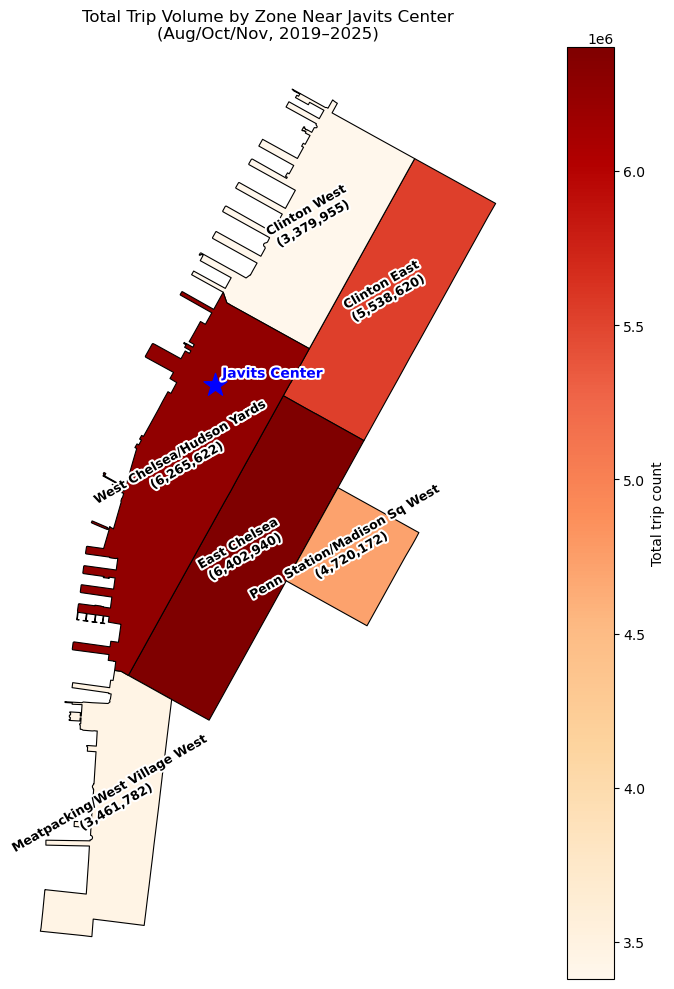

In [29]:
import geopandas as gpd
from shapely.geometry import Point
import matplotlib.patheffects as path_effects

# --- Count total trips touching each relevant zone (as pickup OR dropoff) ---
pu_counts = (
    df.filter(col('PULocationID').isin(relavent_zones))
      .groupBy(col('PULocationID').alias('LocationID'))
      .count()
      .withColumnRenamed('count', 'pu_count')
)

do_counts = (
    df.filter(col('DOLocationID').isin(relavent_zones))
      .groupBy(col('DOLocationID').alias('LocationID'))
      .count()
      .withColumnRenamed('count', 'do_count')
)

zone_trip_counts = (
    pu_counts.join(do_counts, on='LocationID', how='outer')
    .fillna(0)
    .withColumn('total_trip_count', col('pu_count') + col('do_count'))
    .toPandas()
)

# --- Load zone geometry (same shapefile as Weather.ipynb) ---
zones = gpd.read_file("taxi_zones/taxi_zones.shp")
relevant_geom = zones[zones["LocationID"].isin(relavent_zones)].copy()
relevant_geom = relevant_geom.merge(zone_trip_counts, on="LocationID", how="left")
relevant_geom["total_trip_count"] = relevant_geom["total_trip_count"].fillna(0)

# --- Javits Center location (approx, WGS84) ---
javits_point = gpd.GeoSeries(
    [Point(-74.0021, 40.7577)], crs="EPSG:4326"
).to_crs(zones.crs)

# --- Plot heatmap ---
fig, ax = plt.subplots(figsize=(10, 10))
relevant_geom.plot(
    column="total_trip_count",
    cmap="OrRd",
    linewidth=0.8,
    edgecolor="black",
    legend=True,
    legend_kwds={"label": "Total trip count"},
    ax=ax,
)

# Label each zone with name + count — white outline for legibility over any color
for _, row in relevant_geom.iterrows():
    centroid = row.geometry.centroid
    txt = ax.annotate(
        f"{row['zone']}\n({int(row['total_trip_count']):,})",
        xy=(centroid.x, centroid.y),
        ha='center', fontsize=9, weight='bold', color='black',
        rotation=30, rotation_mode='anchor'
    )
    txt.set_path_effects([
        path_effects.Stroke(linewidth=3, foreground='white'),
        path_effects.Normal()
    ])

# Mark Javits Center
javits_point.plot(ax=ax, color='blue', marker='*', markersize=300)
javits_txt = ax.annotate(
    "Javits Center",
    xy=(javits_point.geometry.x.iloc[0], javits_point.geometry.y.iloc[0]),
    xytext=(5, 5), textcoords='offset points', fontsize=10, color='blue', weight='bold'
)
javits_txt.set_path_effects([
    path_effects.Stroke(linewidth=3, foreground='white'),
    path_effects.Normal()
])

ax.set_title("Total Trip Volume by Zone Near Javits Center\n(Aug/Oct/Nov, 2019–2025)")
ax.set_axis_off()
plt.tight_layout()
plt.savefig('Data/plots/zone_trip_heatmap.png', dpi=150)
plt.show()